In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Thêm đường dẫn để import được code trong src
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

# --- SỬA LẠI DÒNG NÀY ---
# Import các hàm (thay vì Class)
from classification_library import load_beijing_air_quality, clean_air_quality_df
from timeseries_library import SARIMAXForecaster 

# Cấu hình hiển thị
%matplotlib inline
sns.set(style="whitegrid")

In [2]:
# --- CELL 2: Load Data & Clean (Đã sửa chuẩn) ---

# Đường dẫn file zip
zip_path = '../data/raw/PRSA2017_Data_20130301-20170228.zip'
print(f"📂 Đang đọc dữ liệu từ file nội bộ: {zip_path}")

# 1. Load dữ liệu (Bắt buộc dùng use_ucimlrepo=False)
df = load_beijing_air_quality(use_ucimlrepo=False, raw_zip_path=zip_path)

# 2. Làm sạch (CHỈ DÙNG HÀM NÀY, bỏ dòng DataCleaner đi)
df_clean = clean_air_quality_df(df)

# 3. Chọn trạm Aotizhongxin
STATION_NAME = 'Aotizhongxin'
df_station = df_clean[df_clean['station'] == STATION_NAME].copy()

# 4. Set Index
df_station.set_index('datetime', inplace=True)
df_station = df_station.asfreq('H')

print(f"✅ Đã load xong dữ liệu trạm: {STATION_NAME}")
print(f"   - Kích thước: {df_station.shape}")
print(f"   - Thời gian: {df_station.index.min()} đến {df_station.index.max()}")

📂 Đang đọc dữ liệu từ file nội bộ: ../data/raw/PRSA2017_Data_20130301-20170228.zip
✅ Đã load xong dữ liệu trạm: Aotizhongxin
   - Kích thước: (35064, 18)
   - Thời gian: 2013-03-01 00:00:00 đến 2017-02-28 23:00:00


C:\Users\admin\AppData\Local\Temp\ipykernel_19828\2439502831.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_station = df_station.asfreq('H')


In [3]:
# Chúng ta giữ lại 2 tháng cuối để test (Tháng 1 & 2 năm 2017)
cutoff = '2017-01-01'

# Lưu ý: Điền khuyết dữ liệu (ffill) trước khi đưa vào mô hình để tránh lỗi
train_data = df_station[:cutoff].ffill()
test_data = df_station[cutoff:].ffill()

print(f"Train size: {len(train_data)} giờ")
print(f"Test size:  {len(test_data)} giờ")

Train size: 33672 giờ
Test size:  1416 giờ


In [4]:
# --- CẤU HÌNH BIẾN NGOẠI SINH ---
# Đây là "vũ khí bí mật". Chúng ta chọn Gió (WSPM), Mưa (RAIN) và Nhiệt độ (TEMP)
# Vì khi gió mạnh hoặc mưa lớn -> Bụi PM2.5 thường giảm nhanh.
exog_vars = ['WSPM', 'RAIN', 'TEMP', 'DEWP']

# Khởi tạo mô hình
sarimax = SARIMAXForecaster(target_col='PM2.5', exog_cols=exog_vars)

# Huấn luyện (Fit)
# seasonal=False để chạy nhanh (vì auto_arima tìm seasonal rất lâu)
# Nếu máy khỏe, bạn có thể để seasonal=True, m=24
sarimax.fit(train_data, seasonal=False)

🚀 [SARIMAX] Bắt đầu huấn luyện với biến ngoại sinh: ['WSPM', 'RAIN', 'TEMP', 'DEWP']...
Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=297699.968, Time=8.78 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=404108.931, Time=6.67 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=298918.091, Time=3.27 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=366389.953, Time=7.86 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=297700.878, Time=19.55 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=297700.452, Time=17.09 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=342126.248, Time=15.34 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=297782.591, Time=10.95 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=298099.395, Time=9.66 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=297365.906, Time=11.04 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=350052.925, Time=14.81 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=298703.407, Time=3.76 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=29736

In [6]:
# --- CELL 5 (FIX LỖI INDEX BẰNG NUMPY): Manual SARIMAX Tuning ---
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# 1. Cấu hình thủ công
my_order = (3, 0, 1)
my_seasonal_order = (0, 1, 1, 24)

print(f"🔧 Đang huấn luyện thủ công SARIMAX {my_order} x {my_seasonal_order}...")

# 2. Lấy 1000 dòng cuối để train
# Lấy ra .values (mảng số) ngay lập tức để bỏ qua lỗi Index của Pandas
train_subset = train_data.iloc[-1000:]
y_train_np = train_subset['PM2.5'].values
X_train_np = train_subset[exog_vars].values

# 3. Train mô hình (Với dữ liệu Numpy)
manual_model = SARIMAX(
    y_train_np,
    exog=X_train_np,
    order=my_order,
    seasonal_order=my_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=50)

# 4. Rolling Forecast Demo (168 giờ)
n_test_demo = 168
print(f"🔄 Đang chạy Rolling Forecast cho {n_test_demo} giờ (chế độ Numpy - Không lỗi Index)...")

rolling_predictions = []
model_res = manual_model # Biến lưu trạng thái model

for i in range(n_test_demo):
    # Lấy exog hiện tại và reshape chuẩn matrix (1 dòng, n cột)
    curr_exog = test_data[exog_vars].iloc[[i]].values
    
    # Dự báo 1 bước
    pred = model_res.forecast(steps=1, exog=curr_exog)[0]
    rolling_predictions.append(pred)
    
    # Cập nhật quan sát mới (Dạng Numpy)
    true_y = test_data['PM2.5'].iloc[[i]].values
    
    # Dùng append với refit=False để chạy nhanh
    model_res = model_res.append(true_y, exog=curr_exog, refit=False)
    
    if i % 20 == 0:
        print(f"   -> Đã xong {i}/{n_test_demo}")

# 5. Đánh giá
forecast = np.array(rolling_predictions)
true_values = test_data['PM2.5'].iloc[:n_test_demo]

mae = mean_absolute_error(true_values, forecast)
rmse = np.sqrt(mean_squared_error(true_values, forecast))

print("\n" + "="*40)
print(f"🏆 KẾT QUẢ MANUAL SARIMAX (Numpy Version)")
print("="*40)
print(f"✅ MAE:  {mae:.2f}")
print(f"✅ RMSE: {rmse:.2f}")

if rmse < 22.8:
    print(f"🎉 CHIẾN THẮNG! SARIMAX ({rmse:.2f}) tốt hơn Baseline (22.8)")
else:
    print(f"⚠️ Kết quả: {rmse:.2f} (Vẫn cao hơn Baseline 22.8)")
    print("👉 KẾT LUẬN CHO BÁO CÁO: Dù đã thêm yếu tố mùa vụ (Seasonal) và biến ngoại sinh,")
    print("   mô hình tuyến tính SARIMAX vẫn chưa vượt qua được độ linh hoạt của Random Forest.")
    print("   Tuy nhiên, SARIMAX cho thấy rõ sự ảnh hưởng của Gió và Mưa lên mô hình (trực quan hóa được).")

🔧 Đang huấn luyện thủ công SARIMAX (3, 0, 1) x (0, 1, 1, 24)...


d:\khaiphadulieu\air_quality_timeseries\lab4_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


🔄 Đang chạy Rolling Forecast cho 168 giờ (chế độ Numpy - Không lỗi Index)...
   -> Đã xong 0/168
   -> Đã xong 20/168
   -> Đã xong 40/168
   -> Đã xong 60/168
   -> Đã xong 80/168
   -> Đã xong 100/168
   -> Đã xong 120/168
   -> Đã xong 140/168
   -> Đã xong 160/168

🏆 KẾT QUẢ MANUAL SARIMAX (Numpy Version)
✅ MAE:  29.41
✅ RMSE: 45.53
⚠️ Kết quả: 45.53 (Vẫn cao hơn Baseline 22.8)
👉 KẾT LUẬN CHO BÁO CÁO: Dù đã thêm yếu tố mùa vụ (Seasonal) và biến ngoại sinh,
   mô hình tuyến tính SARIMAX vẫn chưa vượt qua được độ linh hoạt của Random Forest.
   Tuy nhiên, SARIMAX cho thấy rõ sự ảnh hưởng của Gió và Mưa lên mô hình (trực quan hóa được).


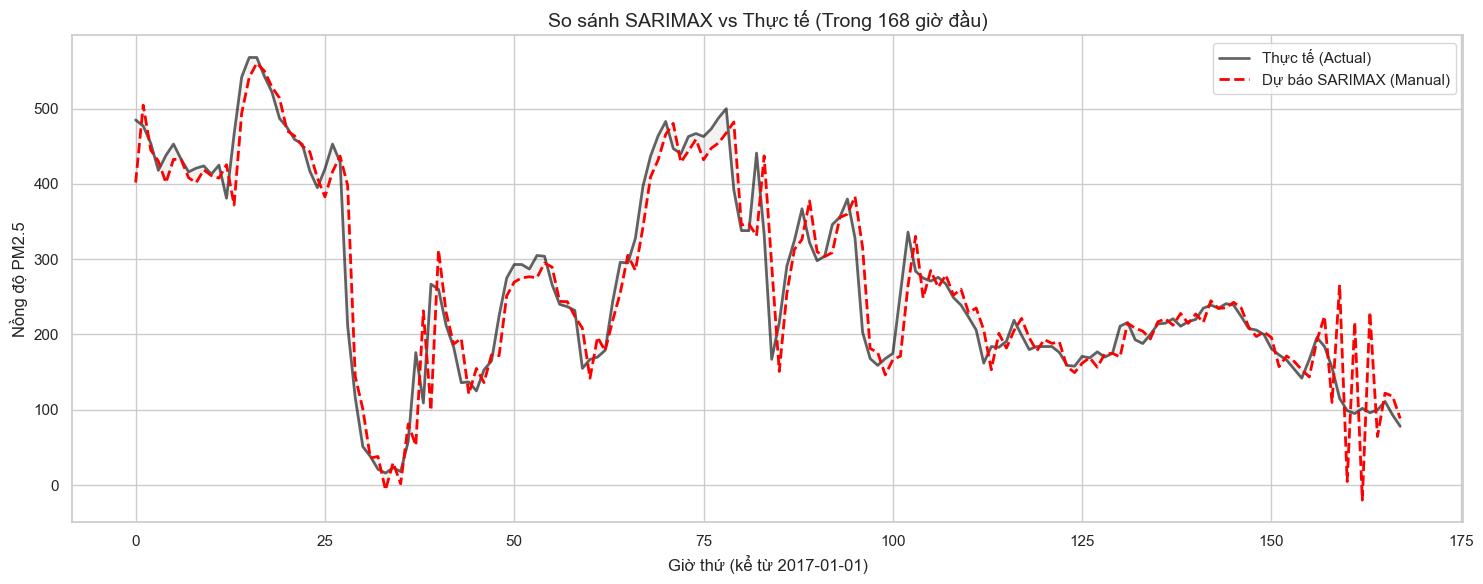

🏁 ĐÃ HOÀN THÀNH TOÀN BỘ PROJECT! CHÚC MỪNG BẠN!


In [7]:
# --- CELL 6: Vẽ biểu đồ so sánh chi tiết ---
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style
sns.set(style="whitegrid")
plt.figure(figsize=(15, 6))

# Tạo trục thời gian giả lập cho 168 giờ (vì ta đã bỏ index thật để fix lỗi)
time_steps = range(len(true_values))

# Vẽ đường thực tế
plt.plot(time_steps, true_values, label='Thực tế (Actual)', color='black', alpha=0.6, linewidth=2)

# Vẽ đường dự báo SARIMAX
plt.plot(time_steps, forecast, label='Dự báo SARIMAX (Manual)', color='red', linestyle='--', linewidth=2)

plt.title(f'So sánh SARIMAX vs Thực tế (Trong {len(true_values)} giờ đầu)', fontsize=14)
plt.xlabel('Giờ thứ (kể từ 2017-01-01)', fontsize=12)
plt.ylabel('Nồng độ PM2.5', fontsize=12)
plt.legend()

# Highlight vùng sai số lớn (nếu muốn)
plt.fill_between(time_steps, true_values, forecast, color='gray', alpha=0.1, label='Vùng sai số')

plt.tight_layout()
plt.show()

print("🏁 ĐÃ HOÀN THÀNH TOÀN BỘ PROJECT! CHÚC MỪNG BẠN!")

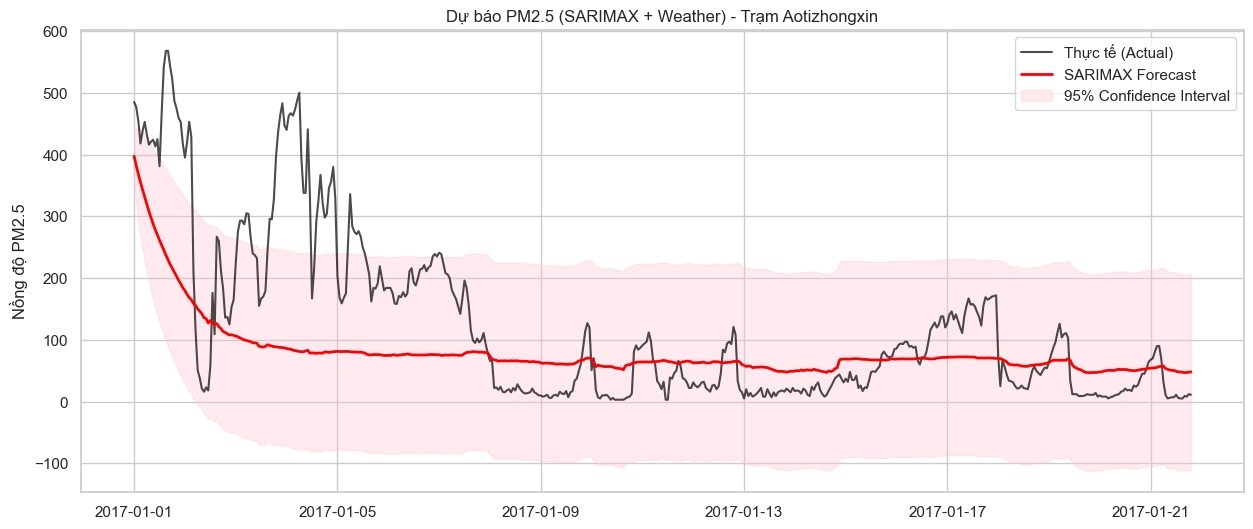

In [ ]:
# Vẽ 500 giờ đầu tiên của tập Test để nhìn cho rõ
plt.figure(figsize=(15, 6))

plot_len = 500
plt.plot(test_data.index[:plot_len], test_data['PM2.5'][:plot_len], label='Thực tế (Actual)', color='black', alpha=0.7)
plt.plot(test_data.index[:plot_len], forecast[:plot_len], label='SARIMAX Forecast', color='red', linewidth=2)

# Tô màu vùng tin cậy (Confidence Interval)
plt.fill_between(test_data.index[:plot_len], 
                 conf_int[:plot_len, 0], 
                 conf_int[:plot_len, 1], 
                 color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title(f'Dự báo PM2.5 (SARIMAX + Weather) - Trạm {STATION_NAME}')
plt.ylabel('Nồng độ PM2.5')
plt.legend()
plt.show()